In [1]:
# --- run me first ---

from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')  # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))  # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


# AAPL Volatility Forecasting — Project Pipeline

This persistent notebook begins the end-to-end project pipeline and will be extended in later lifecycle stages. Stage 04 acquires and validates the trusted raw market-data snapshot.

## Stage 04 — Data acquisition and ingestion

**Source:** Yahoo Finance, accessed programmatically through the open-source `yfinance` client.  
**Dataset:** Unadjusted daily AAPL open, high, low, close, adjusted close, and volume.  
**Parameters:** Ticker and exclusive date bounds come from the local `.env`; the committed `.env.example` documents safe defaults.  
**Raw-data policy:** Preserve the vendor values and append only provenance columns. The filename records the actual minimum and maximum observation dates, so reruns over the same response replace the same snapshot rather than creating timestamp clutter.

In [2]:
import pandas as pd

from src.config import get_key, get_path, load_env
from src.ingestion import fetch_daily_ohlcv, save_raw_snapshot, validate_daily_ohlcv

if not load_env():
    raise FileNotFoundError('Create project/.env from .env.example before running the pipeline.')

SYMBOL = get_key('MARKET_DATA_TICKER', 'AAPL', required=True)
START_DATE = get_key('MARKET_DATA_START', '2020-01-01', required=True)
END_DATE = get_key('MARKET_DATA_END', required=True)
RAW_DIR = get_path('DATA_DIR_RAW', 'data/raw', create=True)

print(f'Request: {SYMBOL}, {START_DATE} through {END_DATE} (exclusive end)')
print('Raw directory:', RAW_DIR.relative_to(ROOT))

Request: AAPL, 2020-01-01 through 2026-08-25 (exclusive end)
Raw directory: data/raw


In [3]:
raw_ohlcv = fetch_daily_ohlcv(SYMBOL, START_DATE, END_DATE)
print('Downloaded shape:', raw_ohlcv.shape)
raw_ohlcv.info()
raw_ohlcv.head()

Downloaded shape: (1669, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   date       1669 non-null   datetime64[s]
 1   open       1669 non-null   float64      
 2   high       1669 non-null   float64      
 3   low        1669 non-null   float64      
 4   close      1669 non-null   float64      
 5   adj_close  1669 non-null   float64      
 6   volume     1669 non-null   int64        
 7   symbol     1669 non-null   str          
 8   source     1669 non-null   str          
dtypes: datetime64[s](1), float64(5), int64(1), str(2)
memory usage: 166.8 KB


Price,date,open,high,low,close,adj_close,volume,symbol,source
0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.271568,135480400,AAPL,Yahoo Finance via yfinance
1,2020-01-03,74.287498,75.144997,74.125000,74.357498,71.568924,146322800,AAPL,Yahoo Finance via yfinance
2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.139175,118387200,AAPL,Yahoo Finance via yfinance
3,2020-01-07,74.959999,75.224998,74.370003,74.597504,71.799927,108872000,AAPL,Yahoo Finance via yfinance
4,2020-01-08,74.290001,76.110001,74.290001,75.797501,72.954895,132079200,AAPL,Yahoo Finance via yfinance


### Validation logic

The reusable validator requires the expected schema and a non-empty response; rejects missing required values, duplicate or unsorted dates, non-datetime dates, non-positive prices, negative volume, and impossible daily high/low relationships. The audit report records shape, coverage, duplicates, and per-column missing counts.

In [4]:
validation_report = validate_daily_ohlcv(raw_ohlcv)
display(pd.Series(validation_report, name='result').to_frame())

,result
valid,True
shape,"(1669, 9)"
date_min,2020-01-02
date_max,2026-08-24
duplicate_dates,0
na_counts,"{'date': 0, 'open': 0, 'high': 0, 'low': 0, 'c..."


In [5]:
raw_path = save_raw_snapshot(raw_ohlcv, RAW_DIR, SYMBOL)
reloaded = pd.read_csv(raw_path, parse_dates=['date'])
assert reloaded.shape == raw_ohlcv.shape
assert (reloaded['date'].to_numpy() == raw_ohlcv['date'].to_numpy()).all()
assert validate_daily_ohlcv(reloaded)['valid']
print('Saved and reloaded:', raw_path.relative_to(ROOT))
print('Rows:', len(reloaded), '| Date range:', reloaded['date'].min().date(), 'to', reloaded['date'].max().date())

Saved and reloaded: data/raw/aapl_ohlcv_20200102_20260824.csv
Rows: 1669 | Date range: 2020-01-02 to 2026-08-24


### Assumptions and risks

- Yahoo Finance is convenient for an educational prototype but is not a contractual market-data feed; availability, corrections, and schema can change. The raw snapshot is committed to preserve the exact input used here.
- `end` is exclusive. The configured cutoff is deliberately fixed for reproducibility and must be advanced intentionally when refreshing data.
- Trading dates come from returned observations; ordinary weekends and market holidays are not treated as missing rows. Exchange-calendar validation will be added later.
- Adjusted close may reflect corporate actions while OHLC fields are unadjusted. Later target construction must choose and document a consistent price basis.
- Basic rules catch structural errors but cannot prove every vendor value is economically correct. Future work should compare distributions, inspect corporate actions, and retain provenance.
- This dataset and pipeline are for coursework and risk-model research, not investment advice or live trading.

### Stage 04 result

The project now has a reproducible acquisition function, a validated raw AAPL daily snapshot, documented source parameters, and a round-trip save/reload check. Future stages will extend this notebook below this point while leaving the raw ingestion step intact.

## Stage 05 — Data storage

The raw vendor snapshot remains CSV for transparency and auditing. This stage creates a Parquet analytical copy because it preserves dtypes and offers compact, efficient columnar IO. Both locations come from `.env`, and reusable functions route by file suffix without hard-coded machine paths.

In [6]:
from src.storage import read_df, validate_roundtrip, write_df

PROCESSED_DIR = get_path('DATA_DIR_PROCESSED', 'data/processed', create=True)
stored_raw = read_df(raw_path, parse_dates=['date'])
processed_path = PROCESSED_DIR / f'{raw_path.stem}.parquet'
write_df(stored_raw, processed_path)
stored_parquet = read_df(processed_path)
print('Processed path:', processed_path.relative_to(ROOT))

Processed path: data/processed/aapl_ohlcv_20200102_20260824.parquet


In [7]:
critical_columns = ['date', 'close', 'volume']
csv_report = validate_roundtrip(raw_ohlcv, stored_raw, critical_columns)
parquet_report = validate_roundtrip(stored_raw, stored_parquet, critical_columns)
storage_validation = pd.DataFrame([csv_report, parquet_report], index=['raw_csv', 'processed_parquet'])
display(storage_validation)
print('CSV bytes:', raw_path.stat().st_size)
print('Parquet bytes:', processed_path.stat().st_size)

,valid,shape_match,columns_match,critical_dtype_matches
raw_csv,True,True,True,"{'date': True, 'close': True, 'volume': True}"
processed_parquet,True,True,True,"{'date': True, 'close': True, 'volume': True}"


CSV bytes: 236362
Parquet bytes: 89818


### Storage assumptions and risks

- The CSV is the immutable, reviewable source snapshot; rerunning with the same observed date range deliberately replaces the same path.
- The Parquet file is currently a lossless analytical copy, not evidence that preprocessing has occurred. Stage 06 will create a clearly documented cleaned dataset.
- Parquet requires `pyarrow`, pinned in `requirements.txt`; the utility raises an installation hint when no engine is available.
- Critical dtype validation covers date, close, and volume. Schema checks should be expanded if later stages add nullable or categorical types.
- Local `.env` paths may point to protected storage, but `.env` and credentials remain excluded from Git.

### Stage 05 result

The pipeline now recreates the project data state from environment-driven locations: it acquires and validates raw CSV data, writes a Parquet analytical copy, reloads both formats, and confirms shape, schema, and critical dtypes.

## Stage 06 — Data preprocessing

This stage turns the stored source snapshot into a validated modeling base table. The strategy is conservative: parse and standardize types, trim text, sort dates, keep the last duplicate-date record, and drop records with missing or economically invalid required values. Prices are not median-filled because invented observations would distort returns and volatility.

In [8]:
from src.cleaning import clean_daily_ohlcv, cleaning_report

preprocessing_input = read_df(raw_path)
cleaned_ohlcv = clean_daily_ohlcv(preprocessing_input)
preprocessing_report = cleaning_report(preprocessing_input, cleaned_ohlcv)
display(pd.Series(preprocessing_report, name='result').to_frame())

,result
rows_before,1669
rows_after,1669
rows_removed,0
duplicate_dates_before,0
duplicate_dates_after,0
missing_required_before,0
missing_required_after,0
date_min,2020-01-02
date_max,2026-08-24


In [9]:
comparison = pd.DataFrame({
    'before': [len(preprocessing_input), preprocessing_input.isna().sum().sum(), preprocessing_input.duplicated('date').sum()],
    'after': [len(cleaned_ohlcv), cleaned_ohlcv.isna().sum().sum(), cleaned_ohlcv.duplicated('date').sum()],
}, index=['rows', 'missing_cells', 'duplicate_dates'])
display(comparison)

cleaned_path = PROCESSED_DIR / f"{SYMBOL.lower()}_ohlcv_clean_{cleaned_ohlcv['date'].min():%Y%m%d}_{cleaned_ohlcv['date'].max():%Y%m%d}.parquet"
write_df(cleaned_ohlcv, cleaned_path)
cleaned_reloaded = read_df(cleaned_path)
assert validate_daily_ohlcv(cleaned_reloaded)['valid']
assert validate_roundtrip(cleaned_ohlcv, cleaned_reloaded, ['date', 'close', 'volume'])['valid']
print('Saved cleaned dataset:', cleaned_path.relative_to(ROOT))
cleaned_reloaded.head()

,before,after
rows,1669,1669
missing_cells,0,0
duplicate_dates,0,0


Saved cleaned dataset: data/processed/aapl_ohlcv_clean_20200102_20260824.parquet


,date,open,high,low,close,adj_close,volume,symbol,source
0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.271545,135480400,AAPL,Yahoo Finance via yfinance
1,2020-01-03,74.287498,75.144997,74.125000,74.357498,71.568909,146322800,AAPL,Yahoo Finance via yfinance
2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.139191,118387200,AAPL,Yahoo Finance via yfinance
3,2020-01-07,74.959999,75.224998,74.370003,74.597504,71.799934,108872000,AAPL,Yahoo Finance via yfinance
4,2020-01-08,74.290001,76.110001,74.290001,75.797501,72.954910,132079200,AAPL,Yahoo Finance via yfinance


### Preprocessing assumptions and tradeoffs

- A row missing date, OHLC, adjusted close, or volume is removed; interpolation or median filling could manufacture a return and understate risk.
- Duplicate dates are sorted stably and the last record is retained, assuming a later vendor record is the correction. Unexpected duplicates remain visible in the cleaning report.
- Rows with non-positive prices, negative volume, or impossible high/low relationships are removed and the final table is revalidated. A large removal count would trigger source investigation rather than blind acceptance.
- Weekends and exchange holidays are not generated. Calendar completeness needs an exchange calendar in a later validation stage.
- Scaling is intentionally deferred until train/test splitting to prevent leakage. Adjusted versus unadjusted price use will be fixed when the target and features are created.

### Stage 06 result

The project now has a reproducible preprocessing layer, an explicit before/after audit, and a separately named cleaned Parquet dataset. The raw CSV is not edited by cleaning, and every transformation is implemented in `src/cleaning.py` for reuse and testing.

## Stage 07 — Outlier analysis

Outliers are analyzed on adjusted-close daily returns. The primary rule flags values outside `Q1 ± 1.5 × IQR`; a three-standard-deviation Z-score provides a comparison. Extreme market moves remain in the canonical data because they are genuine candidates for the volatility events this project is intended to anticipate.

In [10]:
from src.outliers import detect_outliers_zscore, flag_outliers, sensitivity_summary, winsorize_series

outlier_data = cleaned_reloaded.copy()
outlier_data['daily_return'] = outlier_data['adj_close'].pct_change(fill_method=None)
outlier_data['absolute_return'] = outlier_data['daily_return'].abs()
outlier_data = flag_outliers(
    outlier_data, 'daily_return', method='iqr', threshold=1.5, flag_column='return_outlier_iqr'
)
outlier_data['return_outlier_zscore'] = detect_outliers_zscore(outlier_data['daily_return'], threshold=3.0)

flag_counts = outlier_data[['return_outlier_iqr', 'return_outlier_zscore']].sum().astype(int)
print('Outlier counts:')
display(flag_counts.to_frame('count'))
display(outlier_data.loc[outlier_data['return_outlier_iqr'], ['date', 'daily_return', 'absolute_return']].nlargest(10, 'absolute_return'))

Outlier counts:


,count
return_outlier_iqr,82
return_outlier_zscore,25


,date,daily_return,absolute_return
1324,2025-04-09,0.153289,0.153289
50,2020-03-16,-0.128647,0.128647
49,2020-03-13,0.119808,0.119808
146,2020-07-31,0.104689,0.104689
56,2020-03-24,0.100326,0.100326
48,2020-03-12,-0.098755,0.098755
40,2020-03-02,0.093101,0.093101
1320,2025-04-03,-0.092456,0.092456
721,2022-11-10,0.088974,0.088974
65,2020-04-06,0.087237,0.087237


In [11]:
outlier_sensitivity = sensitivity_summary(
    outlier_data['daily_return'], outlier_data['return_outlier_iqr'], winsor_lower=0.01, winsor_upper=0.99
).round(6)
display(outlier_sensitivity)

mean_change_pct = (
    (outlier_sensitivity.loc['iqr_filtered', 'mean'] - outlier_sensitivity.loc['all', 'mean'])
    / abs(outlier_sensitivity.loc['all', 'mean']) * 100
)
std_change_pct = (
    (outlier_sensitivity.loc['iqr_filtered', 'std'] - outlier_sensitivity.loc['all', 'std'])
    / outlier_sensitivity.loc['all', 'std'] * 100
)
print(f'Filtering changes mean by {mean_change_pct:.1f}% and standard deviation by {std_change_pct:.1f}%.')

,count,mean,median,std,min,max
treatment,,,,,,
all,1668,0.001073,0.001140,0.019785,-0.128647,0.153289
iqr_filtered,1586,0.001325,0.001244,0.014707,-0.037305,0.040145
winsorized_1_99,1668,0.000978,0.001140,0.017723,-0.050595,0.051113


Filtering changes mean by 23.5% and standard deviation by -25.7%.


/Users/kevin/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/hx/wzbpnq8x7bzb6dg2sz74gg100000gn/T/matplotlib-4htppf6h because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


/var/folders/hx/wzbpnq8x7bzb6dg2sz74gg100000gn/T/ipykernel_47476/263783497.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(plot_values, tick_labels=['All', 'IQR filtered', 'Winsorized 1–99%'], vert=False)


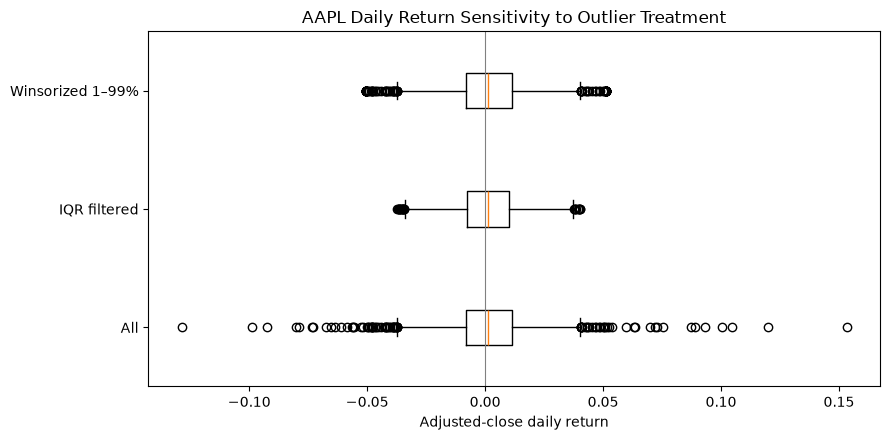

Saved flags: data/processed/aapl_ohlcv_outlier_flags_20200102_20260824.parquet
Saved plot: reports/aapl_daily_return_outlier_sensitivity.png


In [12]:
import matplotlib.pyplot as plt

REPORTS_DIR = get_path('REPORTS_DIR', 'reports', create=True)
plot_values = [
    outlier_data['daily_return'].dropna(),
    outlier_data.loc[~outlier_data['return_outlier_iqr'], 'daily_return'].dropna(),
    winsorize_series(outlier_data['daily_return'], 0.01, 0.99).dropna(),
]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot(plot_values, tick_labels=['All', 'IQR filtered', 'Winsorized 1–99%'], vert=False)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('AAPL Daily Return Sensitivity to Outlier Treatment')
ax.set_xlabel('Adjusted-close daily return')
fig.tight_layout()
outlier_plot_path = REPORTS_DIR / 'aapl_daily_return_outlier_sensitivity.png'
fig.savefig(outlier_plot_path, dpi=150, bbox_inches='tight')
plt.show()

outlier_path = PROCESSED_DIR / f"{SYMBOL.lower()}_ohlcv_outlier_flags_{outlier_data['date'].min():%Y%m%d}_{outlier_data['date'].max():%Y%m%d}.parquet"
write_df(outlier_data, outlier_path)
assert read_df(outlier_path).shape == outlier_data.shape
print('Saved flags:', outlier_path.relative_to(ROOT))
print('Saved plot:', outlier_plot_path.relative_to(ROOT))

### Interpretation, assumptions, and risk

The sensitivity table quantifies how much tail observations influence the return mean and standard deviation. A relatively stable median alongside a lower filtered standard deviation would show that extreme days mainly drive dispersion, which is precisely why deleting them would be dangerous for a volatility project.

IQR is preferred to Z-score for the primary audit because daily returns are heavy-tailed and not reliably normal. However, a global IQR cutoff can mix regimes and uses future sample information; these flags are descriptive annotations, not leakage-safe predictive features. Before treating any flagged row as erroneous, it should be checked against corporate actions and an independent source. Full policy details are in `docs/outliers.md`.

### Stage 07 result

The pipeline now flags extreme adjusted-close returns with two reusable methods, compares three treatments, saves a visual sensitivity artifact, and retains all valid observations for later tail-aware modeling and reporting.